In [21]:
# Import Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import folium
from IPython.display import display
from pandas.core.computation.check import NUMEXPR_INSTALLED
from geopy.distance import great_circle
from sklearn.metrics.pairwise import haversine_distances
from collections import Counter
from scipy.spatial.distance import cdist
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import MinMaxScaler
from ipywidgets import VBox, Label, interact, Output, Text, Button
import ipywidgets as widgets
import math
import seaborn as sns
import random

In [22]:
# Importing CSVs with data
csv_path = "~/Desktop/Climate_related_Disasters_Frequency_2.csv"
data = pd.read_csv(csv_path, skiprows=919, nrows=7)
df = pd.read_csv("~/Desktop/datacentermap.csv")
ds = pd.read_csv("~/Desktop/disastermappings.csv")

In [23]:
# Cleaning data
data_subset = data.iloc[:, 10:]

In [24]:
# Total average number of disasters by category
row_means = data_subset.mean(axis=1)

In [25]:
# Average for every ten years
means_every_ten_columns = []
for i in range(0, len(data_subset.columns), 10):
    subset_columns = data_subset.iloc[:, i:i+10]
    subset_mean = subset_columns.mean(axis=1)
    means_every_ten_columns.append(subset_mean)

In [26]:
# Row labels for output
row_labels = ["Drought", "Extreme Temperature", "Flood", "Landslide", "Storm", "Wildfire", "Total"]

In [27]:
# Unit Test: Check if the lengths of row_means and row_labels are the same
if len(row_means) != len(row_labels):
    print("Error: The number of row means does not match the number of row labels.")
else:
    # Print the average for each row with custom labels
    print("Total average by natural disaster type from 1980 - Present:")
    for idx, mean in enumerate(row_means):
        print(f"{row_labels[idx]}: {mean}")

# Timeframe by decade for disaster averages
print("\nAverage for every ten years:")
# Loop over each row label
for row_label in row_labels:
    # Loop over each ten-year period and its mean
    for i, mean_subset in enumerate(means_every_ten_columns, start=1):
        mean_subset_with_zeros = np.nan_to_num(mean_subset, nan=0.0)  # Replace NaN with zeros
        
        # Ensure we don't exceed the number of years
        year_start = 1980 + (i - 1) * 10
        year_end = min(2020, year_start + 9)  # Limit to 2020 for the present
        if year_start == 2020:
            year_label = "2020 - Present"
        else:
            year_label = f"{year_start} - {year_end}"
        
        # Print the row label, year label, and mean
        print(f"{row_label}: {year_label}: {mean_subset_with_zeros[row_labels.index(row_label)]}")

Total average by natural disaster type from 1980 - Present:
Drought: 1.2
Extreme Temperature: 1.1304347826086956
Flood: 4.575
Landslide: 1.0
Storm: 13.720930232558139
Wildfire: 3.033333333333333
Total: 21.209302325581394

Average for every ten years:
Drought: 1980 - 1989: 1.0
Drought: 1990 - 1999: 1.5
Drought: 2000 - 2009: 1.3333333333333333
Drought: 2010 - 2019: 1.1666666666666667
Drought: 2020 - Present: 1.0
Extreme Temperature: 1980 - 1989: 1.0
Extreme Temperature: 1990 - 1999: 1.4
Extreme Temperature: 2000 - 2009: 1.125
Extreme Temperature: 2010 - 2019: 1.0
Extreme Temperature: 2020 - Present: 1.0
Flood: 1980 - 1989: 2.75
Flood: 1990 - 1999: 5.555555555555555
Flood: 2000 - 2009: 5.6
Flood: 2010 - 2019: 3.8
Flood: 2020 - Present: 5.666666666666667
Landslide: 1980 - 1989: 0.0
Landslide: 1990 - 1999: 1.0
Landslide: 2000 - 2009: 1.0
Landslide: 2010 - 2019: 1.0
Landslide: 2020 - Present: 0.0
Storm: 1980 - 1989: 8.8
Storm: 1990 - 1999: 16.6
Storm: 2000 - 2009: 12.7
Storm: 2010 - 2019: 15

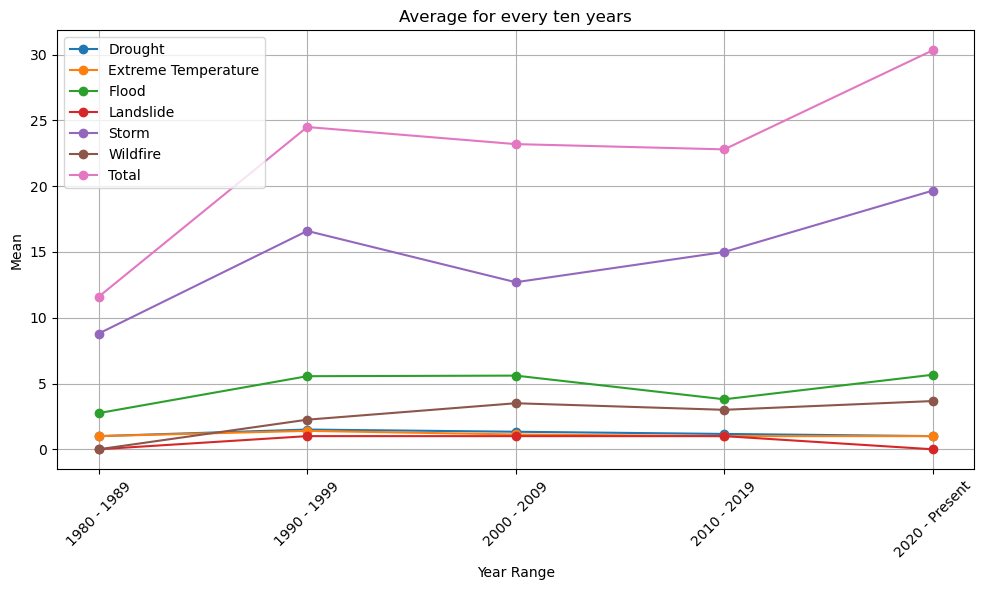

In [28]:
# Averages discovered
averages = {
    ("1980 - 1989", "Drought"): 1.0,
    ("1990 - 1999", "Drought"): 1.5,
    ("2000 - 2009", "Drought"): 1.3333333333333333,
    ("2010 - 2019", "Drought"): 1.1666666666666667,
    ("2020 - Present", "Drought"): 1.0,
    ("1980 - 1989", "Extreme Temperature"): 1.0,
    ("1990 - 1999", "Extreme Temperature"): 1.4,
    ("2000 - 2009", "Extreme Temperature"): 1.125,
    ("2010 - 2019", "Extreme Temperature"): 1.0,
    ("2020 - Present", "Extreme Temperature"): 1.0,
    ("1980 - 1989", "Flood"): 2.75,
    ("1990 - 1999", "Flood"): 5.555555555555555,
    ("2000 - 2009", "Flood"): 5.6,
    ("2010 - 2019", "Flood"): 3.8,
    ("2020 - Present", "Flood"): 5.666666666666667,
    ("1980 - 1989", "Landslide"): 0.0,
    ("1990 - 1999", "Landslide"): 1.0,
    ("2000 - 2009", "Landslide"): 1.0,
    ("2010 - 2019", "Landslide"): 1.0,
    ("2020 - Present", "Landslide"): 0.0,
    ("1980 - 1989", "Storm"): 8.8,
    ("1990 - 1999", "Storm"): 16.6,
    ("2000 - 2009", "Storm"): 12.7,
    ("2010 - 2019", "Storm"): 15.0,
    ("2020 - Present", "Storm"): 19.666666666666668,
    ("1980 - 1989", "Wildfire"): 0.0,
    ("1990 - 1999", "Wildfire"): 2.25,
    ("2000 - 2009", "Wildfire"): 3.5,
    ("2010 - 2019", "Wildfire"): 3.0,
    ("2020 - Present", "Wildfire"): 3.6666666666666665,
    ("1980 - 1989", "Total"): 11.6,
    ("1990 - 1999", "Total"): 24.5,
    ("2000 - 2009", "Total"): 23.2,
    ("2010 - 2019", "Total"): 22.8,
    ("2020 - Present", "Total"): 30.333333333333332,
}

# Plotting
plt.figure(figsize=(10, 6))

for row_label in row_labels:
    x = []
    y = []
    for year_range in ["1980 - 1989", "1990 - 1999", "2000 - 2009", "2010 - 2019", "2020 - Present"]:
        x.append(year_range)
        y.append(averages.get((year_range, row_label), 0))  # Get the corresponding average, default to 0 if not found
    plt.plot(x, y, marker='o', label=row_label)

plt.title("Average for every ten years")
plt.xlabel("Year Range")
plt.ylabel("Mean")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Unnamed: 0    2751
Unnamed: 1    2751
Unnamed: 2    2751
Unnamed: 3    2751
latitude        85
longitude       85
dtype: int64
Unnamed: 0    2665
Unnamed: 1    2665
Unnamed: 2    2665
Unnamed: 3    2665
latitude         0
longitude        0
dtype: int64
(2665, 6)


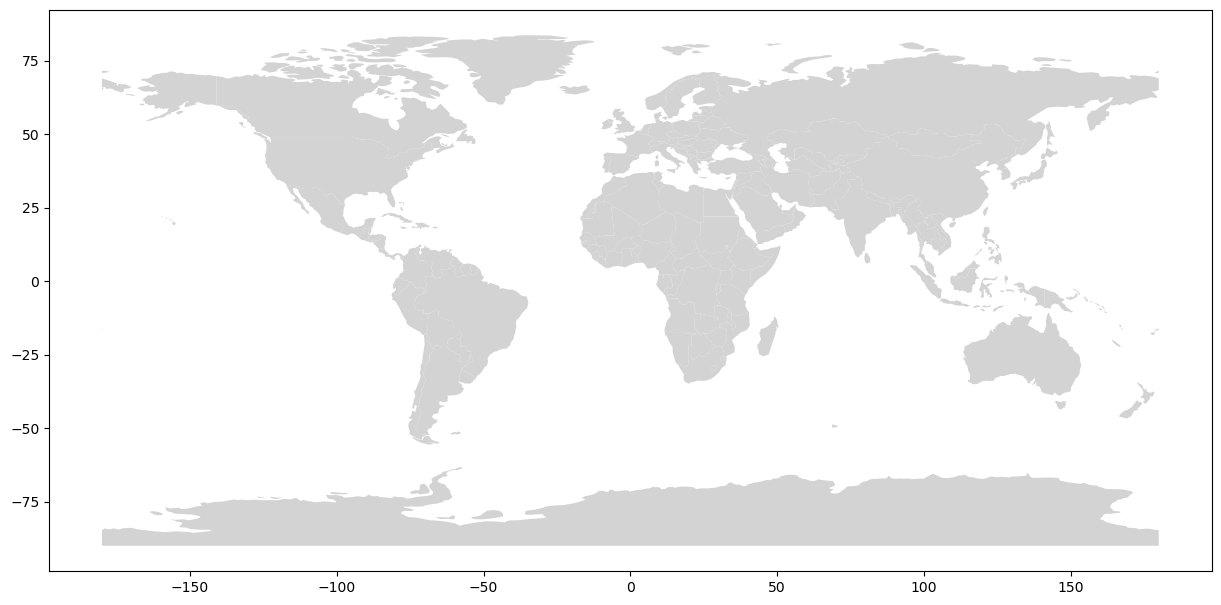

In [29]:
# Check for missing values
print(df.isnull().sum())

# Remove rows with NaN values in 'latitude' or 'longitude'
df = df.dropna(subset=['latitude', 'longitude'])

# Exclude data centers in Alaska, Hawaii, and China by latitude and longitude

# Approximate coordinates for China
china_bounds = {'lat_min': 18, 'lat_max': 53.5, 'lon_min': 73.5, 'lon_max': 135}

# Filter out China
df = df[~((df['latitude'] >= china_bounds['lat_min']) & (df['latitude'] <= china_bounds['lat_max']) & 
          (df['longitude'] >= china_bounds['lon_min']) & (df['longitude'] <= china_bounds['lon_max']))]

# Verify the data after filtering
print(df.isnull().sum())
print(df.shape)

# Convert DataFrame to GeoDataFrame
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Plot using Matplotlib and Geopandas
world = gpd.read_file("~/Desktop/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgray')
plt.show()

# Plot using Folium
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=2)
for _, row in df.iterrows():
    folium.Marker([row['latitude'], row['longitude']]).add_to(m)

# Display the map
display(m)

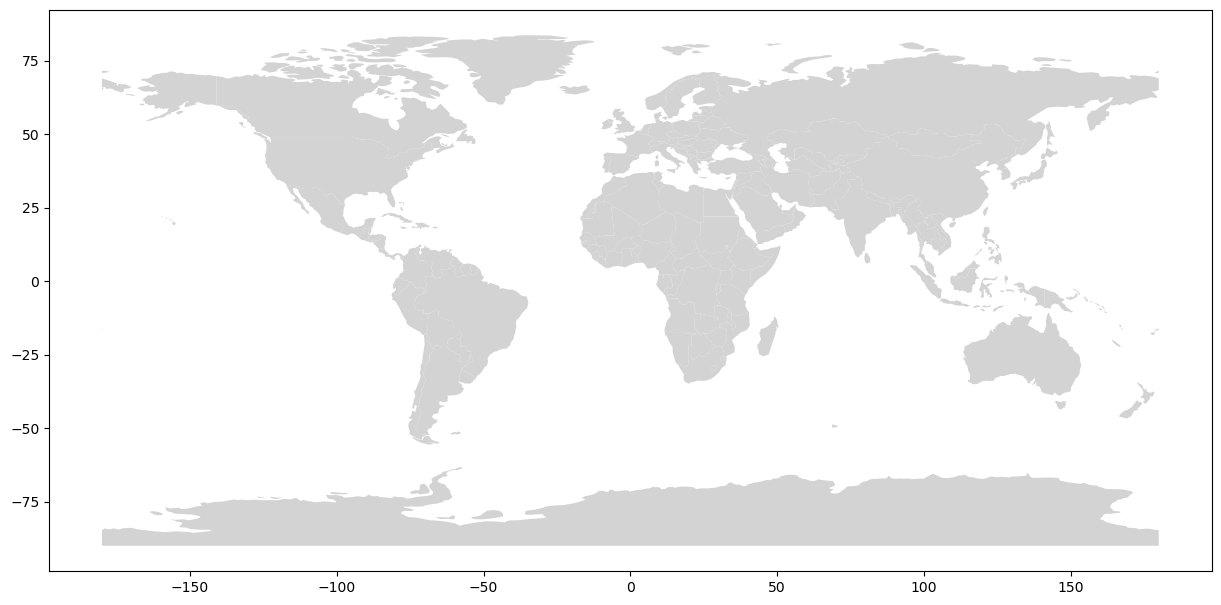

In [30]:
# Check for missing values and remove rows with NaN values in 'latitude' or 'longitude'
ds = ds.dropna(subset=['Latitude', 'Longitude'])

# Approximate coordinates for China
china_bounds = {'lat_min': 18, 'lat_max': 53.5, 'lon_min': 73.5, 'lon_max': 135}

# Filter out China
ds = ds[~((ds['Latitude'] >= china_bounds['lat_min']) & (ds['Latitude'] <= china_bounds['lat_max']) & 
          (ds['Longitude'] >= china_bounds['lon_min']) & (ds['Longitude'] <= china_bounds['lon_max']))]

# Create geometry column using latitude and longitude
geometry = [Point(xy) for xy in zip(ds['Longitude'], ds['Latitude'])]
gdf = gpd.GeoDataFrame(ds, geometry=geometry)

# Plot using Matplotlib and Geopandas
world = gpd.read_file("~/Desktop/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgray')
plt.show()

# Plot using Folium for interactive map
m = folium.Map(location=[ds['Latitude'].mean(), ds['Longitude'].mean()], zoom_start=2)
for _, row in ds.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Location: ({row['Latitude']}, {row['Longitude']})"
    ).add_to(m)

# Display the interactive map
display(m)

In [31]:
# Remove rows where Column N (14th column) contains 'Unnamed'
ds = ds[ds[ds.columns[13]] != 'Unnamed']

# Check for missing values and remove rows with NaN values in 'Latitude' or 'Longitude'
ds = ds.dropna(subset=['Latitude', 'Longitude'])

# Approximate coordinates for China
china_bounds = {'lat_min': 18, 'lat_max': 53.5, 'lon_min': 73.5, 'lon_max': 135}

# Filter out China
ds = ds[~((ds['Latitude'] >= china_bounds['lat_min']) & (ds['Latitude'] <= china_bounds['lat_max']) & 
          (ds['Longitude'] >= china_bounds['lon_min']) & (ds['Longitude'] <= china_bounds['lon_max']))]

# Rename the 14th column to 'Location'
ds.rename(columns={ds.columns[13]: 'Location'}, inplace=True)

# Count the number of occurrences of each unique Latitude and Longitude value along with Location
location_counts = ds.groupby(['Latitude', 'Longitude', 'Location']).size().reset_index(name='Count')

# Sort the DataFrame by 'Count' column in descending order
location_counts_sorted = location_counts.sort_values(by='Count', ascending=False)

# Output the result as a DataFrame without row numbers
print(location_counts_sorted.to_string(index=False))

 Latitude   Longitude                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [32]:
# Remove unwanted 'Unnamed' columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Remove rows with NaN values in 'latitude' or 'longitude'
df = df.dropna(subset=['latitude', 'longitude'])

# Proceed with the rest of your code
# Calculate the closest distance between points
coordinates = df[['latitude', 'longitude']].to_numpy()

# Compute the pairwise distances using the Haversine formula for geodesic distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radius of Earth in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Calculate pairwise distances using cdist with the haversine function
dist_matrix = cdist(coordinates, coordinates, lambda u, v: haversine(u[0], u[1], v[0], v[1]))

# Set diagonal to infinity to exclude zero self-distances
np.fill_diagonal(dist_matrix, np.inf)

# Get the minimum distance for each point
min_distances = dist_matrix.min(axis=1)

# Calculate the average of the minimum distances (i.e., average closest distance)
average_closest_distance = np.mean(min_distances)

# Print the result
print(f"Average distance from event starting point: {average_closest_distance:.2f} km")

Average distance from event starting point: 6.39 km


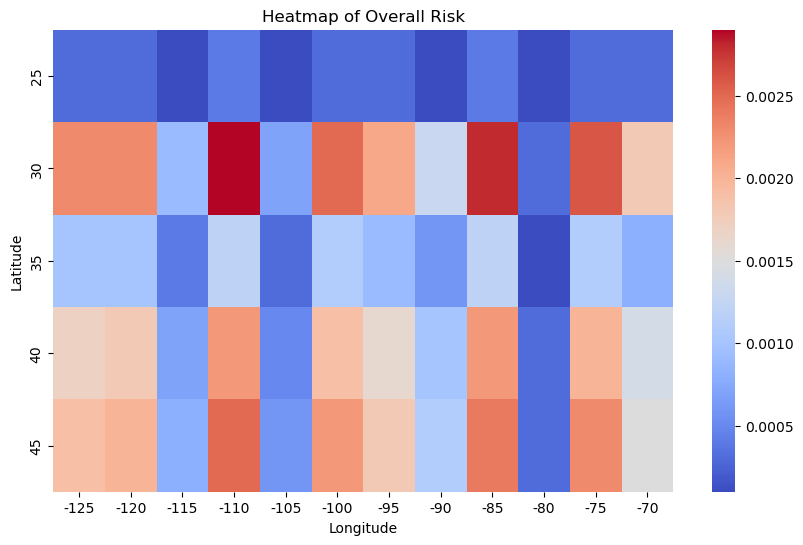

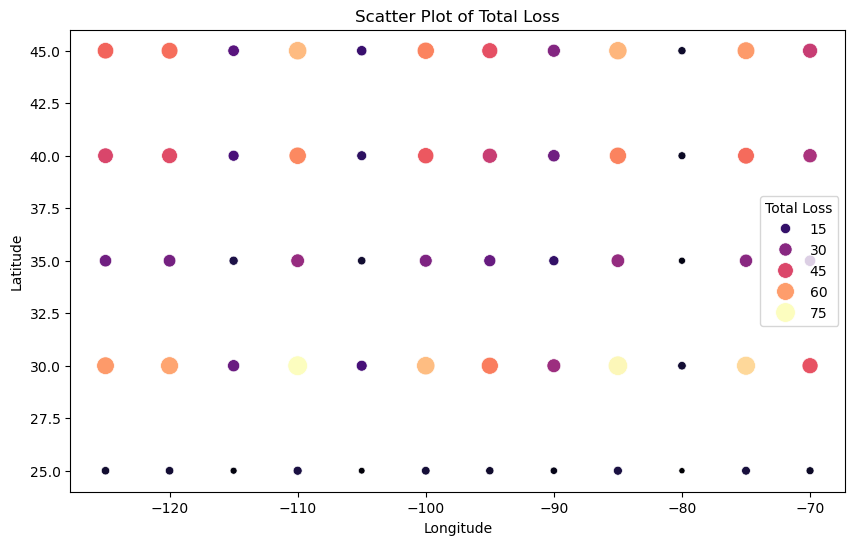

In [33]:
# Constants
LAT_MIN, LAT_MAX = 25.0, 49.0  # Approximate latitude bounds for the contiguous U.S.
LON_MIN, LON_MAX = -125.0, -66.0  # Approximate longitude bounds for the contiguous U.S.
SAMPLE_SIZE = 1000

LANDSLIDE_RISK_PERCENTAGE = 0.44
TEMPERATURE_RISK_PERCENTAGE = 0.6
FLOOD_RISK_PERCENTAGE = 0.09
DROUGHT_RISK_PERCENTAGE = 0.38
WILDFIRE_RISK_PERCENTAGE = 0.25
STORM_RISK_PERCENTAGE = 0.6

SEVERITY_WEIGHTS = {
    "landslide": 0.8,
    "temperature": 0.7,
    "flood": 0.9,
    "drought": 0.6,
    "wildfire": 0.85,
    "storm": 0.75
}

COST_FACTORS = {
    "landslide": 0.5,
    "temperature": 0.3,
    "flood": 0.6,
    "drought": 0.4,
    "wildfire": 0.45,
    "storm": 0.5
}

# Helper Functions
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def generate_random_points(sample_size):
    points = []
    for _ in range(sample_size):
        lat = random.uniform(LAT_MIN, LAT_MAX)
        lon = random.uniform(LON_MIN, LON_MAX)
        points.append((lat, lon))
    return points

def average_distance_from_us(lat, lon, points):
    distances = [haversine_distance(lat, lon, point[0], point[1]) for point in points]
    return sum(distances) / len(distances)

def predict_event_risk(base_risk_percentage, lon, lat):
    random_points = generate_random_points(SAMPLE_SIZE)
    avg_distance = average_distance_from_us(lat, lon, random_points)
    base_probability = abs(math.sin(lat) * math.cos(lon))
    decay_factor = max(1 / (1 + avg_distance), 0.01)
    return base_probability * base_risk_percentage * decay_factor

def predict_weighted_risk_with_loss(lon, lat, build_cost):
    event_probabilities = {
        "landslide": predict_event_risk(LANDSLIDE_RISK_PERCENTAGE, lon, lat),
        "temperature": predict_event_risk(TEMPERATURE_RISK_PERCENTAGE, lon, lat),
        "flood": predict_event_risk(FLOOD_RISK_PERCENTAGE, lon, lat),
        "drought": predict_event_risk(DROUGHT_RISK_PERCENTAGE, lon, lat),
        "wildfire": predict_event_risk(WILDFIRE_RISK_PERCENTAGE, lon, lat),
        "storm": predict_event_risk(STORM_RISK_PERCENTAGE, lon, lat)
    }

    weighted_risks = {}
    losses = {}
    total_loss = 0

    for event, probability in event_probabilities.items():
        weighted_risk = probability * SEVERITY_WEIGHTS[event]
        weighted_risks[event] = round(weighted_risk, 4)

        event_loss = weighted_risk * build_cost * COST_FACTORS[event]
        losses[event] = round(event_loss, 2)
        total_loss += event_loss

    total_loss_percentage = (total_loss / build_cost) * 100 if build_cost else 0

    overall_risk = sum(weighted_risks.values()) / len(weighted_risks)

    return {
        "weighted_risks": weighted_risks,
        "losses": losses,
        "total_loss": round(total_loss, 2),
        "total_loss_percentage": round(total_loss_percentage, 2),
        "overall_risk": round(overall_risk, 4)
    }

# Visualization
lon_range = range(-125, -65, 5)
lat_range = range(25, 50, 5)
build_cost = 10000

grid = [(lon, lat) for lon in lon_range for lat in lat_range]
results = []

for lon, lat in grid:
    prediction = predict_weighted_risk_with_loss(lon, lat, build_cost)
    total_loss = prediction.get("total_loss", 0)
    total_loss_percentage = prediction.get("total_loss_percentage", 0)
    overall_risk = prediction.get("overall_risk", 0)

    results.append({
        "Longitude": lon,
        "Latitude": lat,
        "Overall Risk": overall_risk,
        "Total Loss": total_loss,
        "Total Loss Percentage": total_loss_percentage
    })

df = pd.DataFrame(results)

# Heatmap for Overall Risk
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.pivot(index="Latitude", columns="Longitude", values="Overall Risk"),
    cmap="coolwarm", annot=False
)
plt.title("Heatmap of Overall Risk")
plt.show()

# Scatter Plot for Total Loss
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Longitude", y="Latitude", size="Total Loss", hue="Total Loss",
    data=df, palette="magma", sizes=(20, 200)
)
plt.title("Scatter Plot of Total Loss")
plt.show()

In [34]:
# Constants
LAT_MIN, LAT_MAX = 25.0, 49.0  # Approximate latitude bounds for the contiguous U.S.
LON_MIN, LON_MAX = -125.0, -66.0  # Approximate longitude bounds for the contiguous U.S.
SAMPLE_SIZE = 1000  # Number of random points to sample

# Define specific risk percentages for each event
LANDSLIDE_RISK_PERCENTAGE = 0.44
TEMPERATURE_RISK_PERCENTAGE = 0.6
FLOOD_RISK_PERCENTAGE = 0.09
DROUGHT_RISK_PERCENTAGE = 0.38
WILDFIRE_RISK_PERCENTAGE = 0.25
STORM_RISK_PERCENTAGE = 0.6

# Define severity weights for each event
SEVERITY_WEIGHTS = {
    "landslide": 0.8,
    "temperature": 0.7,
    "flood": 0.9,
    "drought": 0.6,
    "wildfire": 0.85,
    "storm": 0.75
}

# Define cost factors for each event
COST_FACTORS = {
    "landslide": 0.5,  # Percentage of cost lost
    "temperature": 0.3,
    "flood": 0.7,
    "drought": 0.4,
    "wildfire": 0.6,
    "storm": 0.5
}

# Helper functions
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on the Earth (in kilometers).
    """
    R = 6371  # Earth's radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def generate_random_points(sample_size):
    """
    Generate random latitude and longitude points within the U.S. bounds.
    """
    points = []
    for _ in range(sample_size):
        lat = random.uniform(LAT_MIN, LAT_MAX)
        lon = random.uniform(LON_MIN, LON_MAX)
        points.append((lat, lon))
    return points

def average_distance_from_us(lat, lon, points):
    """
    Calculate the average distance from a given point to all random U.S. points.
    """
    distances = [haversine_distance(lat, lon, point[0], point[1]) for point in points]
    return sum(distances) / len(distances)

# Prediction functions
def predict_event_risk(base_percentage, lon, lat):
    random_points = generate_random_points(SAMPLE_SIZE)
    avg_distance = average_distance_from_us(lat, lon, random_points)
    base_probability = abs(math.sin(lat) * math.cos(lon))
    decay_factor = max(1 / (1 + avg_distance), 0.01)
    adjusted_probability = base_probability * base_percentage * decay_factor
    return round(adjusted_probability, 4)

def predict_weighted_risk_with_loss(lon, lat, build_cost):
    # Predict probabilities for each event
    event_probabilities = {
        "landslide": predict_event_risk(LANDSLIDE_RISK_PERCENTAGE, lon, lat),
        "temperature": predict_event_risk(TEMPERATURE_RISK_PERCENTAGE, lon, lat),
        "flood": predict_event_risk(FLOOD_RISK_PERCENTAGE, lon, lat),
        "drought": predict_event_risk(DROUGHT_RISK_PERCENTAGE, lon, lat),
        "wildfire": predict_event_risk(WILDFIRE_RISK_PERCENTAGE, lon, lat),
        "storm": predict_event_risk(STORM_RISK_PERCENTAGE, lon, lat)
    }

    # Calculate weighted risks and losses
    weighted_risks = {}
    losses = {}
    total_loss = 0

    for event, probability in event_probabilities.items():
        weighted_risk = probability * SEVERITY_WEIGHTS[event]
        weighted_risks[event] = round(weighted_risk, 4)

        event_loss = weighted_risk * build_cost * COST_FACTORS[event]
        losses[event] = round(event_loss, 2)
        total_loss += event_loss

    total_loss_percentage = (total_loss / build_cost) * 100 if build_cost else 0

    # Calculate overall risk
    overall_risk = sum(weighted_risks.values()) / len(weighted_risks)

    return {
        "weighted_risks": weighted_risks,
        "losses": losses,
        "total_loss": round(total_loss, 2),
        "total_loss_percentage": round(total_loss_percentage, 2),
        "overall_risk": round(overall_risk, 4)
    }

# Input widgets
lon_input = Text(description="Longitude:")
lat_input = Text(description="Latitude:")
build_cost_input = Text(description="Build Cost:")
predict_button = Button(description="Predict Risk/Loss")
raw_output = Output()
weighted_output = Output()

# Trigger function
def on_predict_clicked_with_loss(_):
    lon = lon_input.value
    lat = lat_input.value
    build_cost = build_cost_input.value

    with raw_output, weighted_output:
        raw_output.clear_output()
        weighted_output.clear_output()

        try:
            lon = float(lon)
            lat = float(lat)
            build_cost = float(build_cost) if build_cost else 0

            risk_scores = predict_weighted_risk_with_loss(lon, lat, build_cost)
            print("Weighted Risk Scores:")
            for risk_type, score in risk_scores["weighted_risks"].items():
                print(f"{risk_type.capitalize()}: {score}")

            print("\nExpected Losses:")
            for loss_type, loss_value in risk_scores["losses"].items():
                print(f"{loss_type.capitalize()}: ${loss_value}")

            print("\nTotal Loss: ${}".format(risk_scores["total_loss"]))
            print("Total Loss Percentage: {}%".format(risk_scores["total_loss_percentage"]))
            print("Overall Risk: {}".format(risk_scores["overall_risk"]))
        except ValueError:
            print("Invalid input. Please enter valid numbers for longitude, latitude, and build cost.")

predict_button.on_click(on_predict_clicked_with_loss)

app = VBox([lon_input, lat_input, build_cost_input, predict_button, raw_output, weighted_output])
app
